# 🌱 Introducción Conceptual a Modelos de Difusión

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mattbarreto/ifts24-lab-pdi-2026/blob/master/009%20-%20modelos_difusion/01_Introduccion_Conceptual_Difusion.ipynb)

**Procesamiento Digital de Imágenes — IFTS24**
Prof. Matias Barreto — 2026

**Unidad 9 · Bloque 1 — 45 minutos**

---

## Al terminar este bloque vas a poder:

1. Explicar qué es un modelo de difusión usando la analogía de la polaroid.
2. Describir las dos direcciones del proceso: forward (agregar ruido) y reverse (eliminar ruido).
3. Visualizar cómo varía el nivel de ruido paso a paso usando el scheduler de diffusers.
4. Distinguir el denoising clásico (filtros) del denoising aprendido por redes neurales.

---

## ◈ Microglosario

| Término | Qué es en lenguaje llano |
|---|---|
| **Difusión** | Proceso matemático que añade ruido gaussiano de forma progresiva a una imagen y luego aprende a revertirlo. |
| **Ruido gaussiano** | Perturbación aleatoria que sigue una distribución normal; es lo que el modelo aprende a identificar y eliminar. |
| **Proceso de Markov** | Cadena de pasos donde cada estado depende solo del estado anterior, no de toda la historia previa. |
| **Denoising** | Operación inversa a la difusión: el modelo predice el ruido presente y lo elimina progresivamente en cada paso. |
| **Espacio latente** | Representación comprimida de una imagen en dimensiones reducidas donde opera el núcleo matemático del modelo. |
| **Scheduler** | Componente que define cuántos pasos de ruido se aplican y con qué magnitud en cada uno de ellos. |

## 1. De lo conocido a lo nuevo: Eliminación de ruido

### ¿Qué ya sabemos?

En módulos anteriores trabajamos con:
- **Ruido en imágenes**: píxeles con valores aleatorios que degradan la calidad
- **Filtros de suavizado**: técnicas para eliminar ruido (promedio, mediana, gaussiano)
- **Procesamiento píxel a píxel**: operaciones que modifican valores sin entender el contenido

### ¿Qué es diferente en los modelos de difusión?

Los métodos tradicionales aplican **una operación matemática directa** (un filtro) para limpiar la imagen.

Los modelos de difusión hacen algo distinto:
1. Aprenden cómo se ve una imagen "limpia" y cómo se ve el ruido
2. Eliminan el ruido **gradualmente**, en múltiples pasos
3. "Entienden" el contenido de la imagen (personas, objetos, texturas)

**Analogía**: Es como revelar una foto polaroid antiguo, donde la imagen aparece de a poco. Pero aquí, la imagen parte muy ruidosa y se va limpiando paso a paso.

## 2. Instalación de librerías

Vamos a usar la librería `diffusers` de Hugging Face, que nos permite trabajar con modelos de difusión pre-entrenados sin necesidad de programar toda la arquitectura.

In [2]:
# si no estan instaladas, Instalamos las librerías necesarias
# descomenta la que corresponda a tu entorno de trabajo
# Esto puede tardar unos minutos la primera vez

#COLAB
#!pip install -q diffusers transformers accelerate torch pillow matplotlib numpy
#!pip install scipy

#local Visual Studio Code
#%pip install -q diffusers transformers accelerate torch pillow matplotlib numpy
#%pip install scipy

In [3]:
# Importamos las librerías que vamos a usar
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from diffusers import DDPMScheduler
import requests
from io import BytesIO

# Configuración para visualización
plt.rcParams['figure.figsize'] = (12, 4)

## 3. Visualización del proceso de difusión

### El proceso tiene dos direcciones:

1. **Forward (hacia adelante)**: Tomamos una imagen limpia y le agregamos ruido progresivamente
2. **Reverse (hacia atrás)**: Tomamos una imagen ruidosa y la limpiamos progresivamente

El modelo de difusión aprende a hacer el proceso **reverse**: partir de ruido y llegar a una imagen limpia.

Vas a visualizar primero el proceso forward para entender cómo funciona.

Imagen cargada. Tamaño: (256, 256)


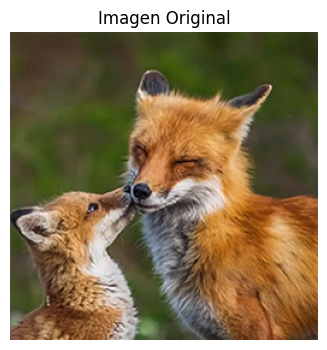

In [4]:
# Cargamos una imagen de ejemplo desde internet
url = "https://foxesworlds.com/wp-content/uploads/FoxesWorld-1.webp"
response = requests.get(url)
imagen_original = Image.open(BytesIO(response.content)).convert('RGB')

# Redimensionamos para que sea más rápido de procesar
imagen_original = imagen_original.resize((256, 256))

# Convertimos a tensor (formato numérico que usan los modelos)
# Los valores quedan entre -1 y 1
imagen_tensor = torch.from_numpy(np.array(imagen_original)).float() / 127.5 - 1
imagen_tensor = imagen_tensor.permute(2, 0, 1).unsqueeze(0)  # Reordenamos dimensiones

print(f"Imagen cargada. Tamaño: {imagen_original.size}")
plt.imshow(imagen_original)
plt.title('Imagen Original')
plt.axis('off')
plt.show()

### Agregando ruido progresivamente (Forward Process)

Ahora vamos a simular el proceso de agregar ruido paso a paso. Vamos a ver cómo la imagen se degrada gradualmente.

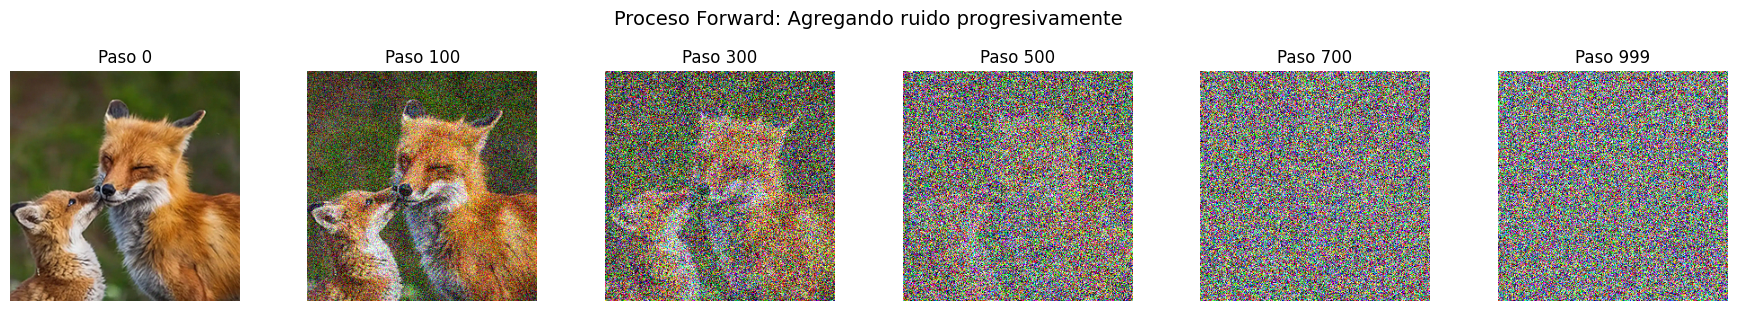

In [5]:
# Creamos un "scheduler" que controla cómo se agrega/elimina ruido
# num_train_timesteps: cantidad de pasos totales en el proceso
scheduler = DDPMScheduler(num_train_timesteps=1000)

# Vas a visualizar la imagen en diferentes momentos del proceso
# timesteps: en qué momento del proceso queremos ver la imagen
# 0 = sin ruido, 999 = máximo ruido
timesteps_a_mostrar = [0, 100, 300, 500, 700, 999]

fig, axes = plt.subplots(1, len(timesteps_a_mostrar), figsize=(18, 3))

for idx, timestep in enumerate(timesteps_a_mostrar):
    # Generamos ruido aleatorio con la misma forma que la imagen
    ruido = torch.randn_like(imagen_tensor)

    # Agregamos el ruido según el timestep
    # add_noise mezcla la imagen original con ruido según el paso
    imagen_con_ruido = scheduler.add_noise(
        imagen_tensor,
        ruido,
        torch.tensor([timestep])
    )

    # Convertimos de tensor a imagen para visualizar
    img_mostrar = (imagen_con_ruido[0].permute(1, 2, 0).numpy() + 1) * 127.5
    img_mostrar = img_mostrar.clip(0, 255).astype(np.uint8)

    axes[idx].imshow(img_mostrar)
    axes[idx].set_title(f'Paso {timestep}')
    axes[idx].axis('off')

plt.suptitle('Proceso Forward: Agregando ruido progresivamente', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### ✎ Para pensar

1. ¿Por qué el modelo necesita *múltiples pasos* para eliminar el ruido en lugar de hacerlo todo de una vez?
2. Si aumentás la cantidad de pasos de difusión de 10 a 1000, ¿qué efecto esperás ver en la imagen con ruido parcial del paso 500?

### ¿Qué observamos?

- En **paso 0**: imagen original sin ruido
- En **pasos intermedios** (100-500): la imagen se va degradando gradualmente
- En **paso 999**: la imagen es prácticamente ruido puro

**Lo importante**: Un modelo de difusión aprende a hacer el camino inverso. Si le damos la imagen del paso 999 (ruido puro), puede reconstruir progresivamente la imagen original.

## 4. Comparación con filtros tradicionales

### Filtro tradicional (promedio)

Vamos a ver qué pasa si usamos un filtro tradicional para eliminar ruido.

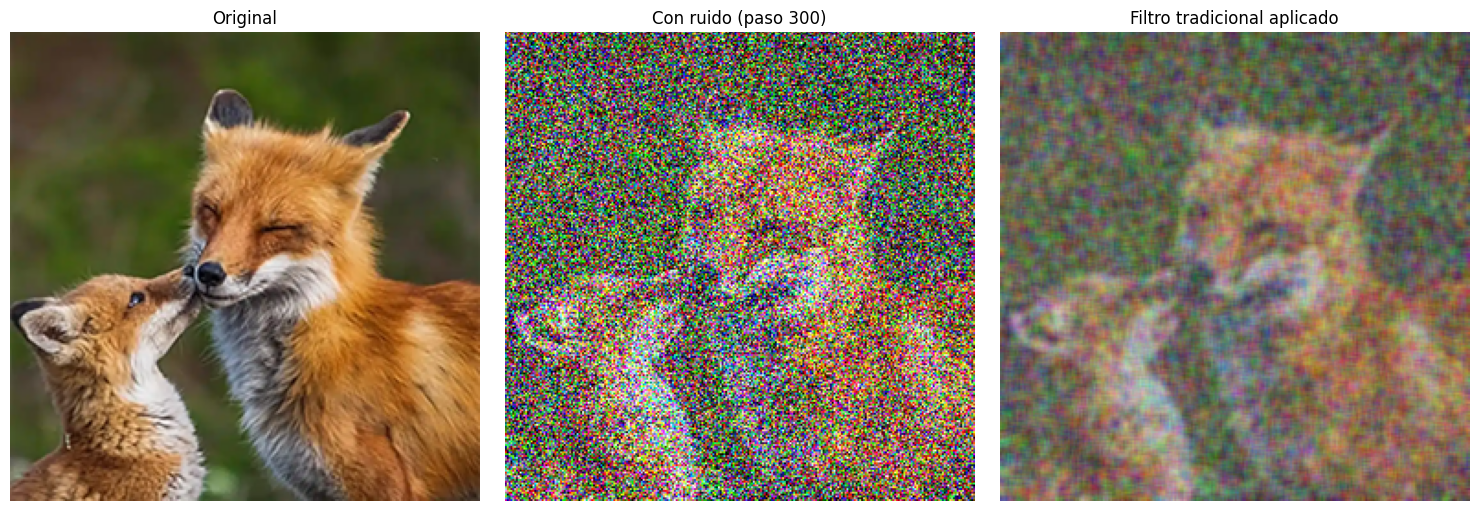

In [6]:
from scipy.ndimage import uniform_filter

# Tomamos la imagen con ruido intermedio (paso 300)
ruido = torch.randn_like(imagen_tensor)
imagen_ruidosa = scheduler.add_noise(imagen_tensor, ruido, torch.tensor([300]))

# Convertimos a numpy para aplicar filtro
img_ruidosa_np = (imagen_ruidosa[0].permute(1, 2, 0).numpy() + 1) * 127.5
img_ruidosa_np = img_ruidosa_np.clip(0, 255).astype(np.uint8)

# Aplicamos filtro de promedio
# size: tamaño de la ventana del filtro (valor modificable para experimentar)
img_filtrada = uniform_filter(img_ruidosa_np, size=(5, 5, 1))

# Visualizamos
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(np.array(imagen_original))
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(img_ruidosa_np)
axes[1].set_title('Con ruido (paso 300)')
axes[1].axis('off')

axes[2].imshow(img_filtrada.astype(np.uint8))
axes[2].set_title('Filtro tradicional aplicado')
axes[2].axis('off')

plt.tight_layout()
plt.show()

### Modelo de difusión (eliminación progresiva de ruido)

Ahora vamos a ver cómo trabaja un modelo de difusión. A diferencia del filtro tradicional que aplica una única operación, el modelo de difusión **elimina el ruido gradualmente** en múltiples pasos.

Vamos a simular este proceso y visualizar cómo la imagen se va limpiando de a poco.

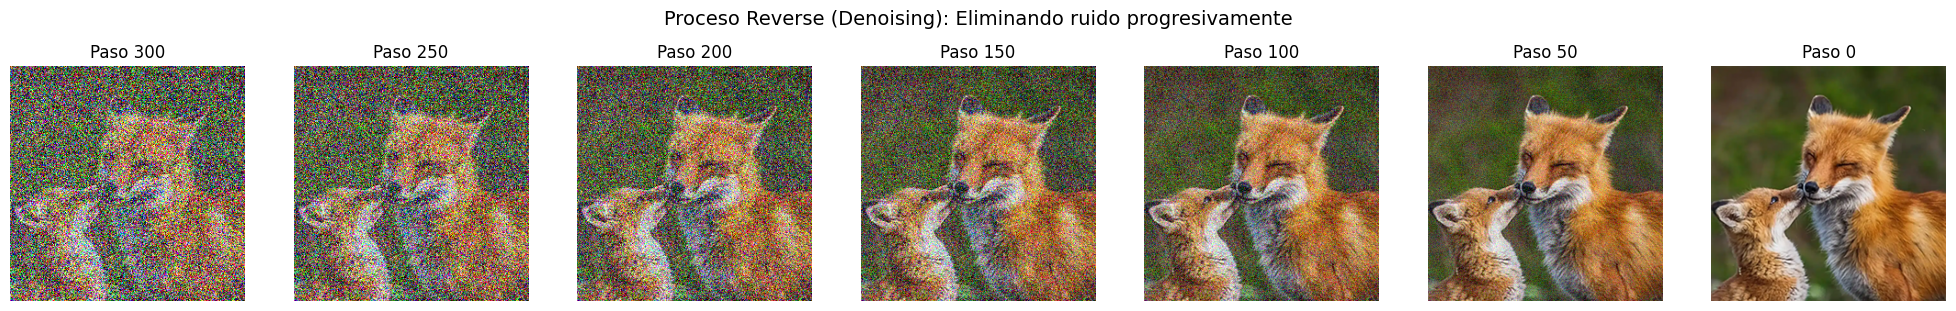


Observá cómo la imagen se va limpiando paso a paso.
En un modelo real, cada paso usa una red neuronal entrenada para predecir y eliminar el ruido.


In [7]:
# Simulamos el proceso de eliminación de ruido (reverse process)
# Partimos de la misma imagen ruidosa y vamos "limpiándola" progresivamente

# Usamos la misma imagen ruidosa que antes (paso 300)
imagen_ruidosa_tensor = imagen_ruidosa.clone()

# Vamos a simular pasos intermedios del denoising
# En un modelo real, cada paso usa la red neuronal para predecir el ruido
# Aquí simplificamos mostrando cómo se reduciría el ruido gradualmente
timesteps_denoising = [300, 250, 200, 150, 100, 50, 0]

fig, axes = plt.subplots(1, len(timesteps_denoising), figsize=(20, 3))

for idx, timestep in enumerate(timesteps_denoising):
    # Simulamos la reducción de ruido
    # Cada paso "acerca" la imagen a la original
    if timestep == 0:
        # En el último paso, mostramos la imagen original
        img_denoised = imagen_tensor
    else:
        # Simulamos el denoising mezclando imagen original con ruido reducido
        # alpha controla cuánto ruido queda (a menor timestep, menos ruido)
        alpha = timestep / 300.0  # Factor de mezcla (modificable para experimentar)
        img_denoised = alpha * imagen_ruidosa_tensor + (1 - alpha) * imagen_tensor

    # Convertimos a imagen para visualizar
    img_mostrar = (img_denoised[0].permute(1, 2, 0).numpy() + 1) * 127.5
    img_mostrar = img_mostrar.clip(0, 255).astype(np.uint8)

    axes[idx].imshow(img_mostrar)
    axes[idx].set_title(f'Paso {timestep}')
    axes[idx].axis('off')

plt.suptitle('Proceso Reverse (Denoising): Eliminando ruido progresivamente', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nObservá cómo la imagen se va limpiando paso a paso.")
print("En un modelo real, cada paso usa una red neuronal entrenada para predecir y eliminar el ruido.")

### ✎ Para pensar

1. ¿En qué se diferencia lo que hace el scheduler de lo que hace la red neuronal dentro del pipeline?
2. ¿Por qué el proceso de difusión parte de ruido puro y no de una imagen negra o completamente blanca?

### ¿Qué vemos?

El filtro tradicional:
- **Suaviza** la imagen
- **Reduce el ruido** pero también **pierde detalles**
- **No recupera información perdida**, solo promedia valores

Un modelo de difusión:
- **Reconstruye detalles** porque "entiende" qué debería haber en la imagen
- **Elimina ruido preservando bordes y texturas**
- Trabaja en **múltiples pasos**, refinando progresivamente

## 5. Diferencias clave: Procesamiento tradicional vs Modelos de difusión

| Aspecto | Procesamiento Tradicional | Modelos de Difusión |
|---------|---------------------------|---------------------|
| **Operación** | Matemática directa (convolución, promedio) | Red neuronal entrenada |
| **Pasos** | Uno solo (aplicás el filtro y listo) | Múltiples (iterativo, progresivo) |
| **Información** | Solo usa píxeles vecinos | Usa "conocimiento" aprendido de miles de imágenes |
| **Resultado** | Suaviza/modifica píxeles | Reconstruye/genera contenido |
| **Velocidad** | Muy rápido (milisegundos) | Más lento (segundos o minutos) |
| **Comprensión** | Sin contexto semántico | Entiende objetos, texturas, contexto |

### ¿Cuándo usar cada uno?

**Filtros tradicionales:**
- Cuando necesitás velocidad
- Para operaciones simples y predecibles
- Cuando no importa perder un poco de detalle

**Modelos de difusión:**
- Cuando necesitás reconstruir o generar contenido
- Para tareas complejas (eliminar objetos, mejorar resolución)
- Cuando el resultado debe ser de alta calidad
- Cuando tenés tiempo y recursos computacionales

## 6. Tipos de tareas que pueden hacer los modelos de difusión

Los modelos de difusión no solo generan imágenes desde cero. Pueden hacer muchas tareas de **procesamiento** de imágenes:

### 1. Generación de imágenes
- **Text-to-Image**: A partir de una descripción de texto, generar una imagen
- Ejemplo: "un gato naranja durmiendo en un sofá azul"

### 2. Inpainting (Rellenado)
- **Eliminar objetos no deseados** de una foto
- **Completar regiones faltantes** en imágenes dañadas
- Ejemplo: Borrar a una persona de una foto grupal

### 3. Super-Resolution (Mejora de resolución)
- **Mejorar la calidad** de imágenes de baja resolución
- **Agregar detalles** que se perdieron por compresión
- Ejemplo: Tomar una foto pixelada y mejorarla

### 4. Image-to-Image (Modificación guiada)
- **Cambiar estilos** de una imagen
- **Modificar características** manteniendo la estructura
- Ejemplo: Convertir un día soleado en día nublado

### 5. Denoising (Eliminación de ruido)
- **Limpiar imágenes ruidosas** preservando detalles
- **Restaurar fotos antiguas** degradadas
- Ejemplo: Mejorar fotos tomadas con poca luz

En el próximo notebook vamos a practicar con algunas de estas aplicaciones usando código simple.

## 7. Conceptos clave para recordar

### Proceso de difusión
- **Forward**: Agregar ruido progresivamente a una imagen limpia
- **Reverse**: Eliminar ruido progresivamente de una imagen ruidosa
- El modelo aprende a hacer el proceso reverse

### Diferencias fundamentales
- No es un filtro matemático simple
- Trabaja en múltiples pasos iterativos
- Usa conocimiento aprendido de miles de imágenes
- Puede "entender" contenido semántico (qué es cada objeto)

### Ventajas
- Resultados de muy alta calidad
- Puede reconstruir detalles perdidos
- Versátil: muchas aplicaciones diferentes

### Limitaciones
- Más lento que filtros tradicionales
- Requiere GPU para ser rápido
- Necesita modelos pre-entrenados (no podemos entrenar desde cero fácilmente)

## 8. Para seguir explorando

### Recursos recomendados

- **Documentación de Diffusers**: https://huggingface.co/docs/diffusers/
- **Hugging Face Diffusion Models Course**: Curso gratuito con teoría y práctica
- **Papers importantes**:
  - "Denoising Diffusion Probabilistic Models" (DDPM, 2020)
  - "High-Resolution Image Synthesis with Latent Diffusion Models" (Stable Diffusion, 2022)

### Próximo paso

En el siguiente notebook vamos a **poner las manos en el código**. Vamos a usar modelos pre-entrenados para hacer inpainting, super-resolution y modificaciones de imágenes. Todo con código simple, sin necesidad de programar arquitecturas complejas.

---

**¿Preguntas o dudas?** Anotá tus consultas para discutirlas en clase.

## ⛰️ Lo que construimos

| Concepto | Qué vimos |
|---|---|
| Proceso forward | Cómo una imagen limpia se convierte en ruido puro paso a paso |
| Proceso reverse | Cómo el modelo aprende a limpiar el ruido en sentido inverso |
| Scheduler | El componente que controla la magnitud del ruido en cada paso |
| Denoising aprendido | Por qué el enfoque de difusión supera a los filtros clásicos |

**Próximo cuaderno:** `02_Paradigmas_y_Modelos_Difusion` — comparamos los distintos enfoques generativos y entendemos por qué la difusión ganó terreno.